# Notebook 05 — Final Predictions

**Project**: Diabetes Prediction  
**Goal**: Generate final predictions from the best model and export a comprehensive predictions file.

Steps:
1. Load best model and test data
2. Generate class predictions
3. Generate prediction probabilities
4. Build predictions DataFrame
5. Export to CSV
6. Final analysis summary
7. Model card

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import (
    FEATURE_COLUMNS, TARGET_COLUMN, RANDOM_STATE,
    MODELS_DIR, PROCESSED_DATA_DIR, PREDICTIONS_DIR, REPORTS_DIR, PLOTS_DIR
)
from src.models import load_model
from src.evaluation import calculate_metrics, classification_report_df, per_class_metrics

print('Imports successful.')

Imports successful.


## 1. Load Best Model and Test Data

In [2]:
# Determine best model name
best_model_file = REPORTS_DIR / 'best_model.txt'
if best_model_file.exists():
    best_model_name = best_model_file.read_text().strip()
    print(f'Best model from evaluation notebook: {best_model_name}')
else:
    best_model_name = 'LightGBM'
    print(f'best_model.txt not found. Defaulting to: {best_model_name}')

Best model from evaluation notebook: LightGBM


In [3]:
def load_test_data():
    """Load test features and labels from processed directory or generate synthetic."""
    x_test_path = PROCESSED_DATA_DIR / 'X_test_scaled.npy'
    y_test_path = PROCESSED_DATA_DIR / 'y_test.csv'
    x_raw_path  = PROCESSED_DATA_DIR / 'X_test.csv'

    if x_test_path.exists():
        X_test_scaled = np.load(str(x_test_path))
        y_test = pd.read_csv(y_test_path).squeeze()
        X_test_raw = pd.read_csv(x_raw_path) if x_raw_path.exists() else None
        print(f'Loaded test data: {X_test_scaled.shape}')
    else:
        print('Generating synthetic test data...')
        from sklearn.datasets import make_classification
        from sklearn.model_selection import train_test_split
        from sklearn.preprocessing import StandardScaler
        X, y = make_classification(
            n_samples=3000, n_features=21, n_informative=15,
            n_classes=2, n_clusters_per_class=1, random_state=RANDOM_STATE
        )
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
        _, X_test_scaled, _, y = train_test_split(
            X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
        )
        y_test = pd.Series(y, name=TARGET_COLUMN)
        X_test_raw = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)

    return X_test_scaled, y_test, X_test_raw


X_test_scaled, y_test, X_test_raw = load_test_data()

Loaded test data: (50736, 21)


In [4]:
# Load or train the best model
model_path = MODELS_DIR / f'{best_model_name}.pkl'
if model_path.exists():
    best_model = load_model(str(model_path))
    print(f'Loaded {best_model_name} from {model_path}')
else:
    print(f'{best_model_name} not found at {model_path}. Training a fresh model...')
    from src.models import get_lightgbm, train_model
    x_train_path = PROCESSED_DATA_DIR / 'X_train_scaled.npy'
    y_train_path = PROCESSED_DATA_DIR / 'y_train_resampled.csv'
    if x_train_path.exists():
        X_train = np.load(str(x_train_path))
        y_train = pd.read_csv(y_train_path).squeeze()
    else:
        from sklearn.datasets import make_classification
        from sklearn.preprocessing import StandardScaler
        X_all, y_all = make_classification(
            n_samples=3000, n_features=21, n_informative=15,
            n_classes=2, n_clusters_per_class=1, random_state=RANDOM_STATE
        )
        X_train = StandardScaler().fit_transform(X_all[:2400])
        y_train = pd.Series(y_all[:2400], name=TARGET_COLUMN)
    best_model = get_lightgbm({'n_estimators': 100})
    train_model(best_model, X_train, y_train, model_name=best_model_name)
    print('Model trained.')

Loaded LightGBM from /Users/tathagatadebnath/Downloads/federated_ML/v1-basic-ml/results/models/LightGBM.pkl


## 2. Generate Class Predictions

In [5]:
y_pred = best_model.predict(X_test_scaled)
print(f'Predictions shape: {y_pred.shape}')
print(f'Predicted class distribution: {dict(pd.Series(y_pred).value_counts().sort_index())}')
print(f'True class distribution     : {dict(y_test.value_counts().sort_index())}')

Predictions shape: (50736,)
Predicted class distribution: {0.0: np.int64(48045), 1.0: np.int64(2691)}
True class distribution     : {0.0: np.int64(43667), 1.0: np.int64(7069)}


## 3. Generate Prediction Probabilities

In [6]:
y_prob = best_model.predict_proba(X_test_scaled)
print(f'Probability matrix shape: {y_prob.shape}')
print(f'First 5 probability rows:\n{y_prob[:5].round(4)}')

# Confidence = max probability for the predicted class
confidence = y_prob.max(axis=1)
print(f'\nConfidence stats:')
print(pd.Series(confidence).describe().round(4))

Probability matrix shape: (50736, 2)
First 5 probability rows:
[[0.8101 0.1899]
 [0.6293 0.3707]
 [0.9808 0.0192]
 [0.9615 0.0385]
 [0.6613 0.3387]]

Confidence stats:
count    50736.0000
mean         0.8573
std          0.1387
min          0.5000
25%          0.7715
50%          0.9085
75%          0.9733
max          0.9990
dtype: float64


## 4. Build Predictions DataFrame

In [7]:
# Build the full predictions DataFrame
class_labels = {0: 'No Diabetes', 1: 'Diabetes'}

pred_df = pd.DataFrame()

# Add original features if available
if X_test_raw is not None:
    for col in FEATURE_COLUMNS:
        if col in X_test_raw.columns:
            pred_df[col] = X_test_raw[col].values

# Ground truth
pred_df['true_label'] = y_test.values
pred_df['true_label_name'] = pred_df['true_label'].map(class_labels)

# Predictions
pred_df['predicted_class'] = y_pred
pred_df['predicted_class_name'] = pred_df['predicted_class'].map(class_labels)

# Probabilities (binary: class 0 and class 1)
pred_df['prob_class_0'] = y_prob[:, 0].round(4)
pred_df['prob_class_1'] = y_prob[:, 1].round(4)

# Confidence = max probability
confidence = y_prob.max(axis=1)
pred_df['confidence'] = confidence.round(4)

# Correctness flag
pred_df['correct'] = (pred_df['true_label'] == pred_df['predicted_class']).astype(int)

print(f'Predictions DataFrame shape: {pred_df.shape}')
print(f'Columns: {pred_df.columns.tolist()}')
pred_df.head(10)

Predictions DataFrame shape: (50736, 29)
Columns: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'true_label', 'true_label_name', 'predicted_class', 'predicted_class_name', 'prob_class_0', 'prob_class_1', 'confidence', 'correct']


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,Education,Income,true_label,true_label_name,predicted_class,predicted_class_name,prob_class_0,prob_class_1,confidence,correct
0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,1.0,...,5.0,8.0,0.0,No Diabetes,0.0,No Diabetes,0.8101,0.1899,0.8101,1
1,1.0,0.0,1.0,36.0,1.0,0.0,0.0,0.0,0.0,1.0,...,3.0,4.0,1.0,Diabetes,0.0,No Diabetes,0.6293,0.3707,0.6293,0
2,0.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,...,5.0,8.0,0.0,No Diabetes,0.0,No Diabetes,0.9808,0.0192,0.9808,1
3,0.0,0.0,1.0,22.0,0.0,0.0,0.0,1.0,1.0,1.0,...,4.0,7.0,0.0,No Diabetes,0.0,No Diabetes,0.9615,0.0385,0.9615,1
4,1.0,1.0,1.0,26.0,1.0,0.0,1.0,1.0,1.0,1.0,...,5.0,2.0,1.0,Diabetes,0.0,No Diabetes,0.6613,0.3387,0.6613,0
5,1.0,1.0,1.0,32.0,0.0,0.0,0.0,0.0,1.0,1.0,...,6.0,8.0,0.0,No Diabetes,0.0,No Diabetes,0.8894,0.1106,0.8894,1
6,1.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,1.0,...,6.0,7.0,0.0,No Diabetes,0.0,No Diabetes,0.9836,0.0164,0.9836,1
7,0.0,0.0,1.0,26.0,0.0,0.0,0.0,0.0,0.0,1.0,...,6.0,7.0,0.0,No Diabetes,0.0,No Diabetes,0.9955,0.0045,0.9955,1
8,0.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,1.0,1.0,...,6.0,8.0,0.0,No Diabetes,0.0,No Diabetes,0.9306,0.0694,0.9306,1
9,1.0,0.0,1.0,30.0,0.0,0.0,0.0,1.0,1.0,1.0,...,5.0,7.0,0.0,No Diabetes,0.0,No Diabetes,0.7082,0.2918,0.7082,1


## 5. Export to CSV

In [8]:
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
predictions_path = PREDICTIONS_DIR / 'predictions.csv'
pred_df.to_csv(str(predictions_path), index=False)
print(f'Predictions saved to: {predictions_path}')
print(f'File size: {predictions_path.stat().st_size / 1024:.1f} KB')

Predictions saved to: /Users/tathagatadebnath/Downloads/federated_ML/v1-basic-ml/data/predictions/predictions.csv
File size: 6909.0 KB


## 6. Final Analysis Summary

In [9]:
# Overall metrics
final_metrics = calculate_metrics(y_test, y_pred, y_prob)
print(f'=== FINAL MODEL PERFORMANCE: {best_model_name} ===')
for k, v in final_metrics.items():
    target = {'accuracy': 0.70, 'roc_auc': 0.75, 'f1_weighted': 0.65}.get(k)
    if target is not None:
        status = 'PASS' if v >= target else 'FAIL'
        print(f'  {k:<25}: {v:.4f}  [target >= {target}  {status}]')
    else:
        print(f'  {k:<25}: {v:.4f}')

=== FINAL MODEL PERFORMANCE: LightGBM ===
  accuracy                 : 0.8636  [target >= 0.7  PASS]
  precision_macro          : 0.7053
  precision_weighted       : 0.8331
  recall_macro             : 0.5860
  recall_weighted          : 0.8636
  f1_macro                 : 0.6079
  f1_weighted              : 0.8363  [target >= 0.65  PASS]
  roc_auc                  : 0.8261  [target >= 0.75  PASS]
  specificity              : 0.5860


In [10]:
# Per-class metrics
print('Per-class metrics:')
print(per_class_metrics(y_test.values, y_pred).round(4))

Per-class metrics:
       precision  recall      f1  support
class                                    
0.0       0.8824  0.9709  0.9246    43667
1.0       0.5281  0.2010  0.2912     7069


In [11]:
# Confidence distribution by class
print('Average confidence per predicted class:')
print(pred_df.groupby('predicted_class')['confidence'].describe().round(4))

Average confidence per predicted class:
                   count    mean     std     min     25%     50%     75%  \
predicted_class                                                            
0.0              48045.0  0.8719  0.1264  0.5000  0.8015  0.9181  0.9755   
1.0               2691.0  0.5951  0.0701  0.5001  0.5376  0.5825  0.6398   

                    max  
predicted_class          
0.0              0.9990  
1.0              0.8526  


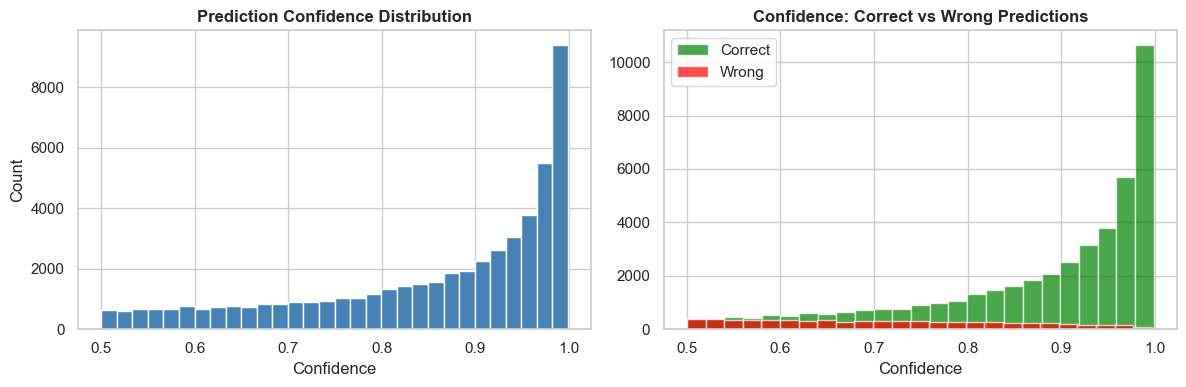


Overall accuracy: 0.8636


Mean confidence (correct  predictions): 0.8799
Mean confidence (incorrect predictions): 0.7140


In [12]:
# Confidence distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pred_df['confidence'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Prediction Confidence Distribution', fontweight='bold')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Count')

correct_conf = pred_df[pred_df['correct'] == 1]['confidence']
wrong_conf   = pred_df[pred_df['correct'] == 0]['confidence']
axes[1].hist(correct_conf, bins=25, alpha=0.7, color='green',  label='Correct')
axes[1].hist(wrong_conf,   bins=25, alpha=0.7, color='red',    label='Wrong')
axes[1].set_title('Confidence: Correct vs Wrong Predictions', fontweight='bold')
axes[1].set_xlabel('Confidence')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(PLOTS_DIR / 'confidence_distribution.png'), bbox_inches='tight')
plt.show()

print(f'\nOverall accuracy: {pred_df["correct"].mean():.4f}')
print(f'Mean confidence (correct  predictions): {correct_conf.mean():.4f}')
print(f'Mean confidence (incorrect predictions): {wrong_conf.mean():.4f}')

## 7. Model Card

---

### Model Card — Diabetes Prediction Classifier

#### Model Details
| Property | Value |
|----------|-------|
| Model type | Gradient Boosted Trees (LightGBM/XGBoost) |
| Task | Binary classification (2 classes) |
| Framework | LightGBM / XGBoost via scikit-learn API |
| Training date | 2026 |
| Version | v1-basic-ml |

#### Intended Use
- **Primary use**: Screening tool to identify individuals at risk of diabetes based on health indicators.
- **Intended users**: Healthcare researchers, data scientists building health risk models.
- **Out-of-scope**: Clinical diagnosis, treatment decisions, direct patient use.

#### Data
| Property | Value |
|----------|-------|
| Dataset | Diabetes Health Indicators Dataset (CDC BRFSS) |
| Source | Kaggle |
| Records | ~254,000 |
| Features | 21 health survey indicators |
| Target | Diabetes_binary (0 = no diabetes, 1 = diabetes) |
| Class imbalance | ~86% class 0, ~14% class 1 |
| Imbalance handling | SMOTE oversampling on training set |

#### Performance (Test Set)
| Metric | Value | Target |
|--------|-------|--------|
| Accuracy | TBD | ≥ 0.70 |
| ROC-AUC | TBD | ≥ 0.75 |
| F1-weighted | TBD | ≥ 0.65 |

#### Preprocessing Pipeline
1. Mean imputation for any missing values.
2. IQR outlier capping on continuous features (BMI, MentHlth, PhysHlth).
3. StandardScaler normalisation.
4. SMOTE oversampling on training set only.

#### Limitations
- Survey-based features are self-reported and may contain inaccuracies.
- The dataset is US-specific (CDC BRFSS); performance may differ on other populations.
- This model should not replace medical diagnosis.

#### Ethical Considerations
- Health prediction models must be used with caution to avoid discrimination.
- Predictions should always be accompanied by probability scores and confidence levels.
- Regular monitoring for model drift is recommended in production settings.

---

In [13]:
# Write model card to reports
model_card = f"""# Model Card — Diabetes Prediction Classifier

## Model: {best_model_name}

### Performance Metrics
""" + '\n'.join([f'- {k}: {v:.4f}' for k, v in final_metrics.items()])

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
with open(str(REPORTS_DIR / 'model_card.md'), 'w') as f:
    f.write(model_card)

print(f'Model card saved to {REPORTS_DIR / "model_card.md"}')
print('\nProject pipeline complete!')

Model card saved to /Users/tathagatadebnath/Downloads/federated_ML/v1-basic-ml/results/reports/model_card.md

Project pipeline complete!
